# Analyse des DPO $\beta$-Hyperparameter-Sweep Experiments

Systematischer Vergleich des Seq2Seq-Übersetzungsmodells (`facebook/mbart-large-50`) unter Variation des DPO-Temperaturparameters $\beta$:

$$\mathcal{L}_{\text{DPO}}(\theta; \pi_{\text{ref}}) = - \mathbb{E}_{(x, y_w, y_l)} \left[ \log \sigma \left( \beta \log \frac{\pi_\theta(y_w | x)}{\pi_{\text{ref}}(y_w | x)} - \beta \log \frac{\pi_\theta(y_l | x)}{\pi_{\text{ref}}(y_l | x)} \right) \right]$$

**Modellvarianten:**
- **SFT Baseline** (Referenzmodell, $\beta = 0$)
- **DPO $\beta = 0{,}01$** (Aggressive Präferenzanpassung)
- **DPO $\beta = 0{,}05$** (Moderates Alignment)
- **DPO $\beta = 0{,}10$** (Standard-Baseline)
- **DPO $\beta = 0{,}20$** (Konservative Regularisierung)
- **DPO $\beta = 0{,}50$** (Starke Referenzbindung)

In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, '.git')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser('~/Documents/Master Thesis'))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

print('Arbeitsverzeichnis gesetzt auf:', os.getcwd())

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150


Arbeitsverzeichnis gesetzt auf: /Users/fietescheel/Documents/Master Thesis


## 1. Evaluationsergebnisse laden
Einlesen der Gesamtauswertung auf dem Lebenshilfe-Testset ($N=37$).

In [2]:
SUMMARY_CSV = os.path.join(REPO_ROOT, 'results/evaluation/dpo_beta_comparison_summary.csv')
DETAILS_CSV = os.path.join(REPO_ROOT, 'results/evaluation/dpo_beta_comparison_details.csv')

df_summary = pd.read_csv(SUMMARY_CSV)
display(df_summary)

df_details = pd.read_csv(DETAILS_CSV) if os.path.exists(DETAILS_CSV) else None


,Modell,model_key,beta,model_path,r_style_mean,r_style_std,r_sem_as_mean,r_sem_as_std,sim_ref_mean,composite_reward_mean,...,rouge_l_mean,avg_gen_tokens,avg_src_tokens,compression_ratio_mean,truncation_rate_pct,flesch_de_mean,lix_mean,passive_ratio_mean,genitive_ratio_mean,nominal_ratio_mean
0,SFT Baseline,SFT Baseline,0.00,results/models/sft,0.571281,0.287312,0.900868,0.040987,0.879805,0.736074,...,0.138842,161.216216,916.459459,0.383757,48.648649,36.258438,43.798537,0.0,0.019461,0.028730
1,DPO (Beta = 0.01),DPO (Beta = 0.01),0.01,results/models/dpo_beta_sweep/dpo_beta_001,0.851792,0.054047,0.864179,0.059977,0.860624,0.857986,...,0.146587,194.081081,916.459459,0.455690,64.864865,46.448621,37.435050,0.0,0.001757,0.018144
2,DPO (Beta = 0.05),DPO (Beta = 0.05),0.05,results/models/dpo_beta_sweep/dpo_beta_005,0.699630,0.247057,0.893728,0.045027,0.873940,0.796679,...,0.143064,180.918919,916.459459,0.429245,51.351351,42.523918,41.014442,0.0,0.012818,0.028790
3,DPO (Beta = 0.10),DPO (Beta = 0.10),0.10,results/models/dpo_beta_sweep/dpo_beta_010,0.641406,0.279006,0.896780,0.042633,0.875891,0.769093,...,0.141367,174.945946,916.459459,0.413864,56.756757,39.706571,41.835831,0.0,0.015181,0.027085
4,DPO (Beta = 0.20),DPO (Beta = 0.20),0.20,results/models/dpo_beta_sweep/dpo_beta_020,0.633616,0.282544,0.903706,0.043610,0.877632,0.768661,...,0.146087,174.351351,916.459459,0.413600,70.270270,40.554752,41.121647,0.0,0.015309,0.029834
5,DPO (Beta = 0.50),DPO (Beta = 0.50),0.50,results/models/dpo_beta_sweep/dpo_beta_050,0.638337,0.281109,0.900982,0.044645,0.876837,0.769660,...,0.142306,172.810811,916.459459,0.402192,56.756757,41.427699,41.223980,0.0,0.015933,0.029936


## 2. Visualisierungen: Pareto-Frontier, Composite Reward & Satzabbrüche

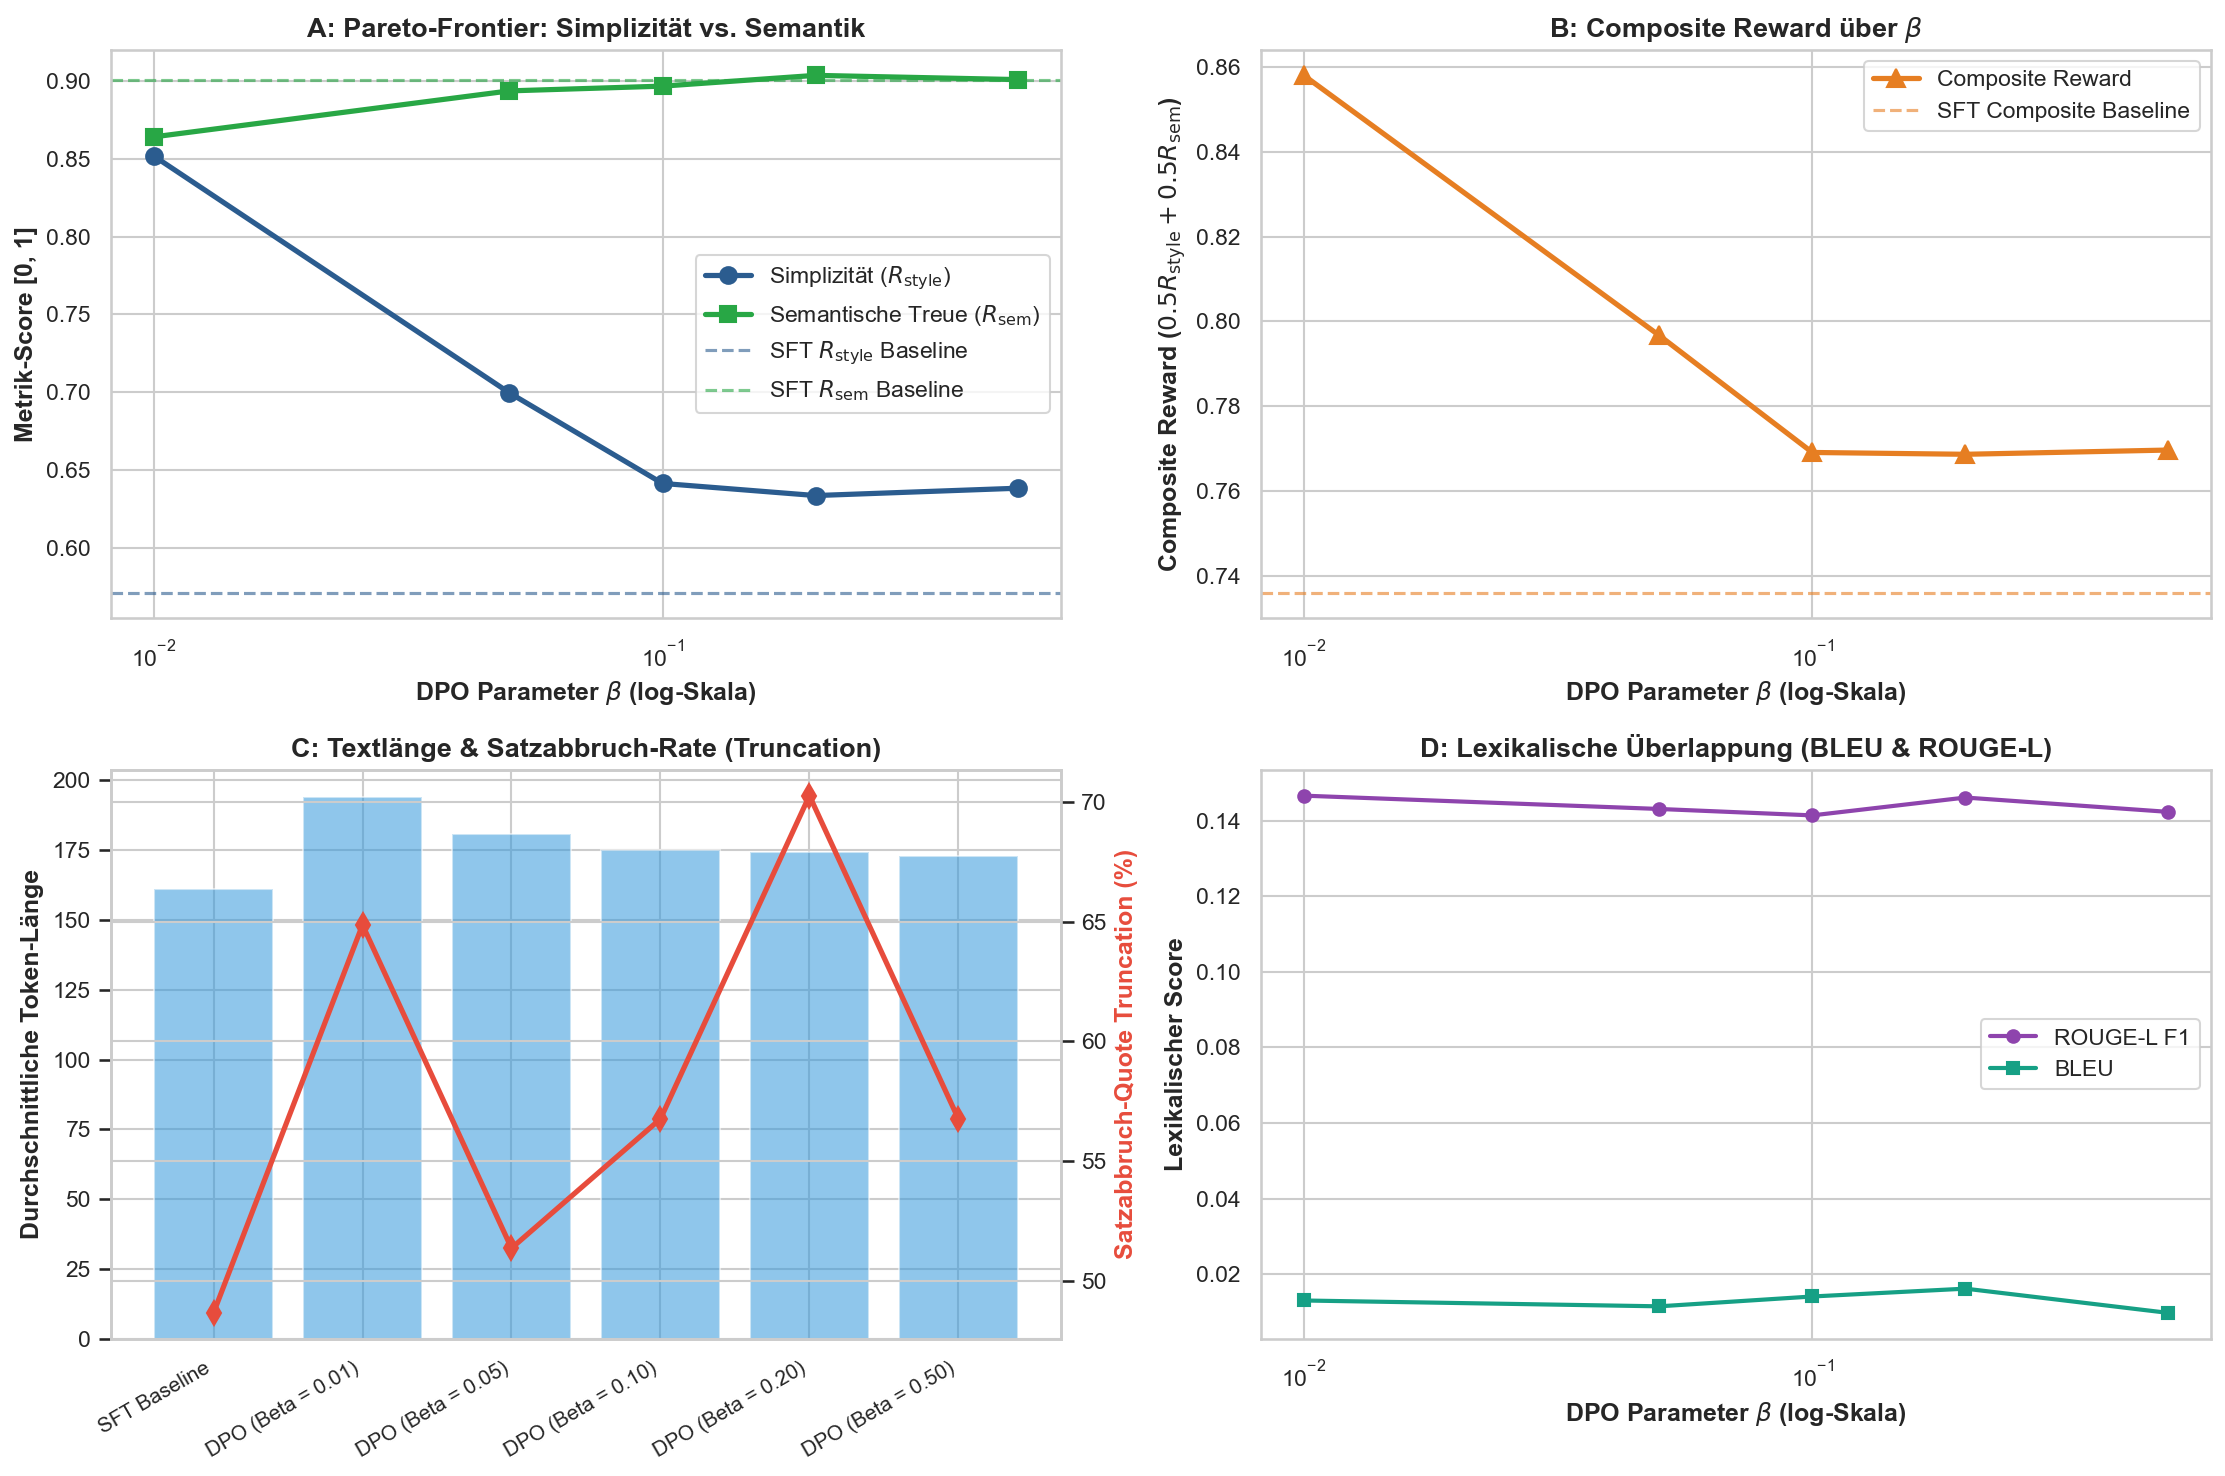

Plot gespeichert unter: /Users/fietescheel/Documents/Master Thesis/results/plots/experiments/dpo_beta_sweep/dpo_beta_analysis_multi_panel.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Panel 1: Pareto-Trade-off Style vs. Semantik
dpo_df = df_summary[df_summary['beta'] > 0].sort_values('beta')
axes[0, 0].plot(dpo_df['beta'], dpo_df['r_style_mean'], marker='o', linewidth=2.5, markersize=8, label=r'Simplizität ($R_{\mathrm{style}}$)', color='#2b5c8f')
axes[0, 0].plot(dpo_df['beta'], dpo_df['r_sem_as_mean'], marker='s', linewidth=2.5, markersize=8, label=r'Semantische Treue ($R_{\mathrm{sem}}$)', color='#28a745')
sft_style = df_summary[df_summary['beta'] == 0]['r_style_mean'].values[0] if (df_summary['beta'] == 0).any() else 0.5038
sft_sem = df_summary[df_summary['beta'] == 0]['r_sem_as_mean'].values[0] if (df_summary['beta'] == 0).any() else 0.8698
axes[0, 0].axhline(sft_style, color='#2b5c8f', linestyle='--', alpha=0.6, label=r'SFT $R_{\mathrm{style}}$ Baseline')
axes[0, 0].axhline(sft_sem, color='#28a745', linestyle='--', alpha=0.6, label=r'SFT $R_{\mathrm{sem}}$ Baseline')
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel(r'DPO Parameter $\beta$ (log-Skala)', fontweight='bold')
axes[0, 0].set_ylabel('Metrik-Score [0, 1]', fontweight='bold')
axes[0, 0].set_title('A: Pareto-Frontier: Simplizität vs. Semantik', fontweight='bold', fontsize=13)
axes[0, 0].legend(loc='best', frameon=True)

# Panel 2: Composite Reward
axes[0, 1].plot(dpo_df['beta'], dpo_df['composite_reward_mean'], marker='^', linewidth=2.5, markersize=9, color='#e67e22', label='Composite Reward')
sft_comp = df_summary[df_summary['beta'] == 0]['composite_reward_mean'].values[0] if (df_summary['beta'] == 0).any() else 0.6868
axes[0, 1].axhline(sft_comp, color='#e67e22', linestyle='--', alpha=0.6, label='SFT Composite Baseline')
axes[0, 1].set_xscale('log')
axes[0, 1].set_xlabel(r'DPO Parameter $\beta$ (log-Skala)', fontweight='bold')
axes[0, 1].set_ylabel(r'Composite Reward ($0.5 R_{\mathrm{style}} + 0.5 R_{\mathrm{sem}}$)', fontweight='bold')
axes[0, 1].set_title(r'B: Composite Reward über $\beta$', fontweight='bold', fontsize=13)
axes[0, 1].legend(loc='best', frameon=True)

# Panel 3: Truncation Rate (%) & Textlänge
ax3_twin = axes[1, 0].twinx()
x_pos = np.arange(len(df_summary))
bars = axes[1, 0].bar(x_pos, df_summary['avg_gen_tokens'], alpha=0.55, color='#3498db', label='Avg Gen Tokens')
line = ax3_twin.plot(x_pos, df_summary['truncation_rate_pct'], marker='d', color='#e74c3c', linewidth=2.5, markersize=8, label='Truncation Rate (%)')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(df_summary['Modell'], rotation=30, ha='right', fontsize=10)
axes[1, 0].set_ylabel('Durchschnittliche Token-Länge', fontweight='bold')
ax3_twin.set_ylabel('Satzabbruch-Quote Truncation (%)', color='#e74c3c', fontweight='bold')
axes[1, 0].set_title('C: Textlänge & Satzabbruch-Rate (Truncation)', fontweight='bold', fontsize=13)

# Panel 4: BLEU & ROUGE-L
axes[1, 1].plot(dpo_df['beta'], dpo_df['rouge_l_mean'], marker='o', color='#8e44ad', linewidth=2, label='ROUGE-L F1')
axes[1, 1].plot(dpo_df['beta'], dpo_df['bleu_mean'], marker='s', color='#16a085', linewidth=2, label='BLEU')
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel(r'DPO Parameter $\beta$ (log-Skala)', fontweight='bold')
axes[1, 1].set_ylabel('Lexikalischer Score', fontweight='bold')
axes[1, 1].set_title('D: Lexikalische Überlappung (BLEU & ROUGE-L)', fontweight='bold', fontsize=13)
axes[1, 1].legend(loc='best', frameon=True)

plt.tight_layout()
plot_save_path = os.path.join(REPO_ROOT, 'results/plots/experiments/dpo_beta_sweep/dpo_beta_analysis_multi_panel.png')
os.makedirs(os.path.dirname(plot_save_path), exist_ok=True)
plt.savefig(plot_save_path, dpi=300)
plt.show()
print('Plot gespeichert unter:', plot_save_path)


## 3. Qualitativer Text-Vergleich (Beispielübersetzungen)
Side-by-Side Vergleich der generierten Übersetzungen über die verschiedenen $\beta$-Werte.

In [4]:
if df_details is not None and len(df_details) > 0:
    sample_indices = [0, 1, 2]
    for idx in sample_indices:
        print('=' * 90)
        print(f'BEISPIEL {idx + 1}')
        print('=' * 90)
        first_row = df_details[df_details['model_name'] == df_details['model_name'].unique()[0]].iloc[idx]
        print(f"[AS-ORIGINAL]:\n{first_row.get('as_text', '')[:250]}...\n")
        print(f"[GOLD LS-REFERENZ]:\n{first_row.get('ls_ref_text', '')[:250]}...\n")
        print('-' * 90)
        for m in df_details['model_name'].unique():
            m_row = df_details[df_details['model_name'] == m].iloc[idx]
            print(f"[{m}] (Style={m_row.get('r_style', 0):.3f} | SBERT={m_row.get('r_sem_as', 0):.3f} | Tokens={m_row.get('gen_tokens', 0)} | Trunc={m_row.get('is_truncated', False)}):\n{m_row.get('generated_text', '')}\n")


BEISPIEL 1
[AS-ORIGINAL]:
Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dring...

[GOLD LS-REFERENZ]:
Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeutet: Mehrere Gruppen haben diesen Text geschrieben. Sie haben Ihre Meinung aufgeschrieben. Und sie haben Ihre Ideen aufgeschrieben. ...

------------------------------------------------------------------------------------------
[SFT Baseline] (Style=0.852 | SBERT=0.810 | Tokens=191 | Trunc=True):
Was ist die Entlohnung für Menschen, die in einer Werkstatt arbeiten? In der Stadt Kiel gibt es eine Werkstatt. Dort arbeiten viele Menschen. Die Mitarbeiter arbeiten 6 bis 8 Stunden am Tag. Und die Mitarbeiter haben einen Vertrag. Der Vertrag heißt: Arbeitsvertrag. Der Lohn von den